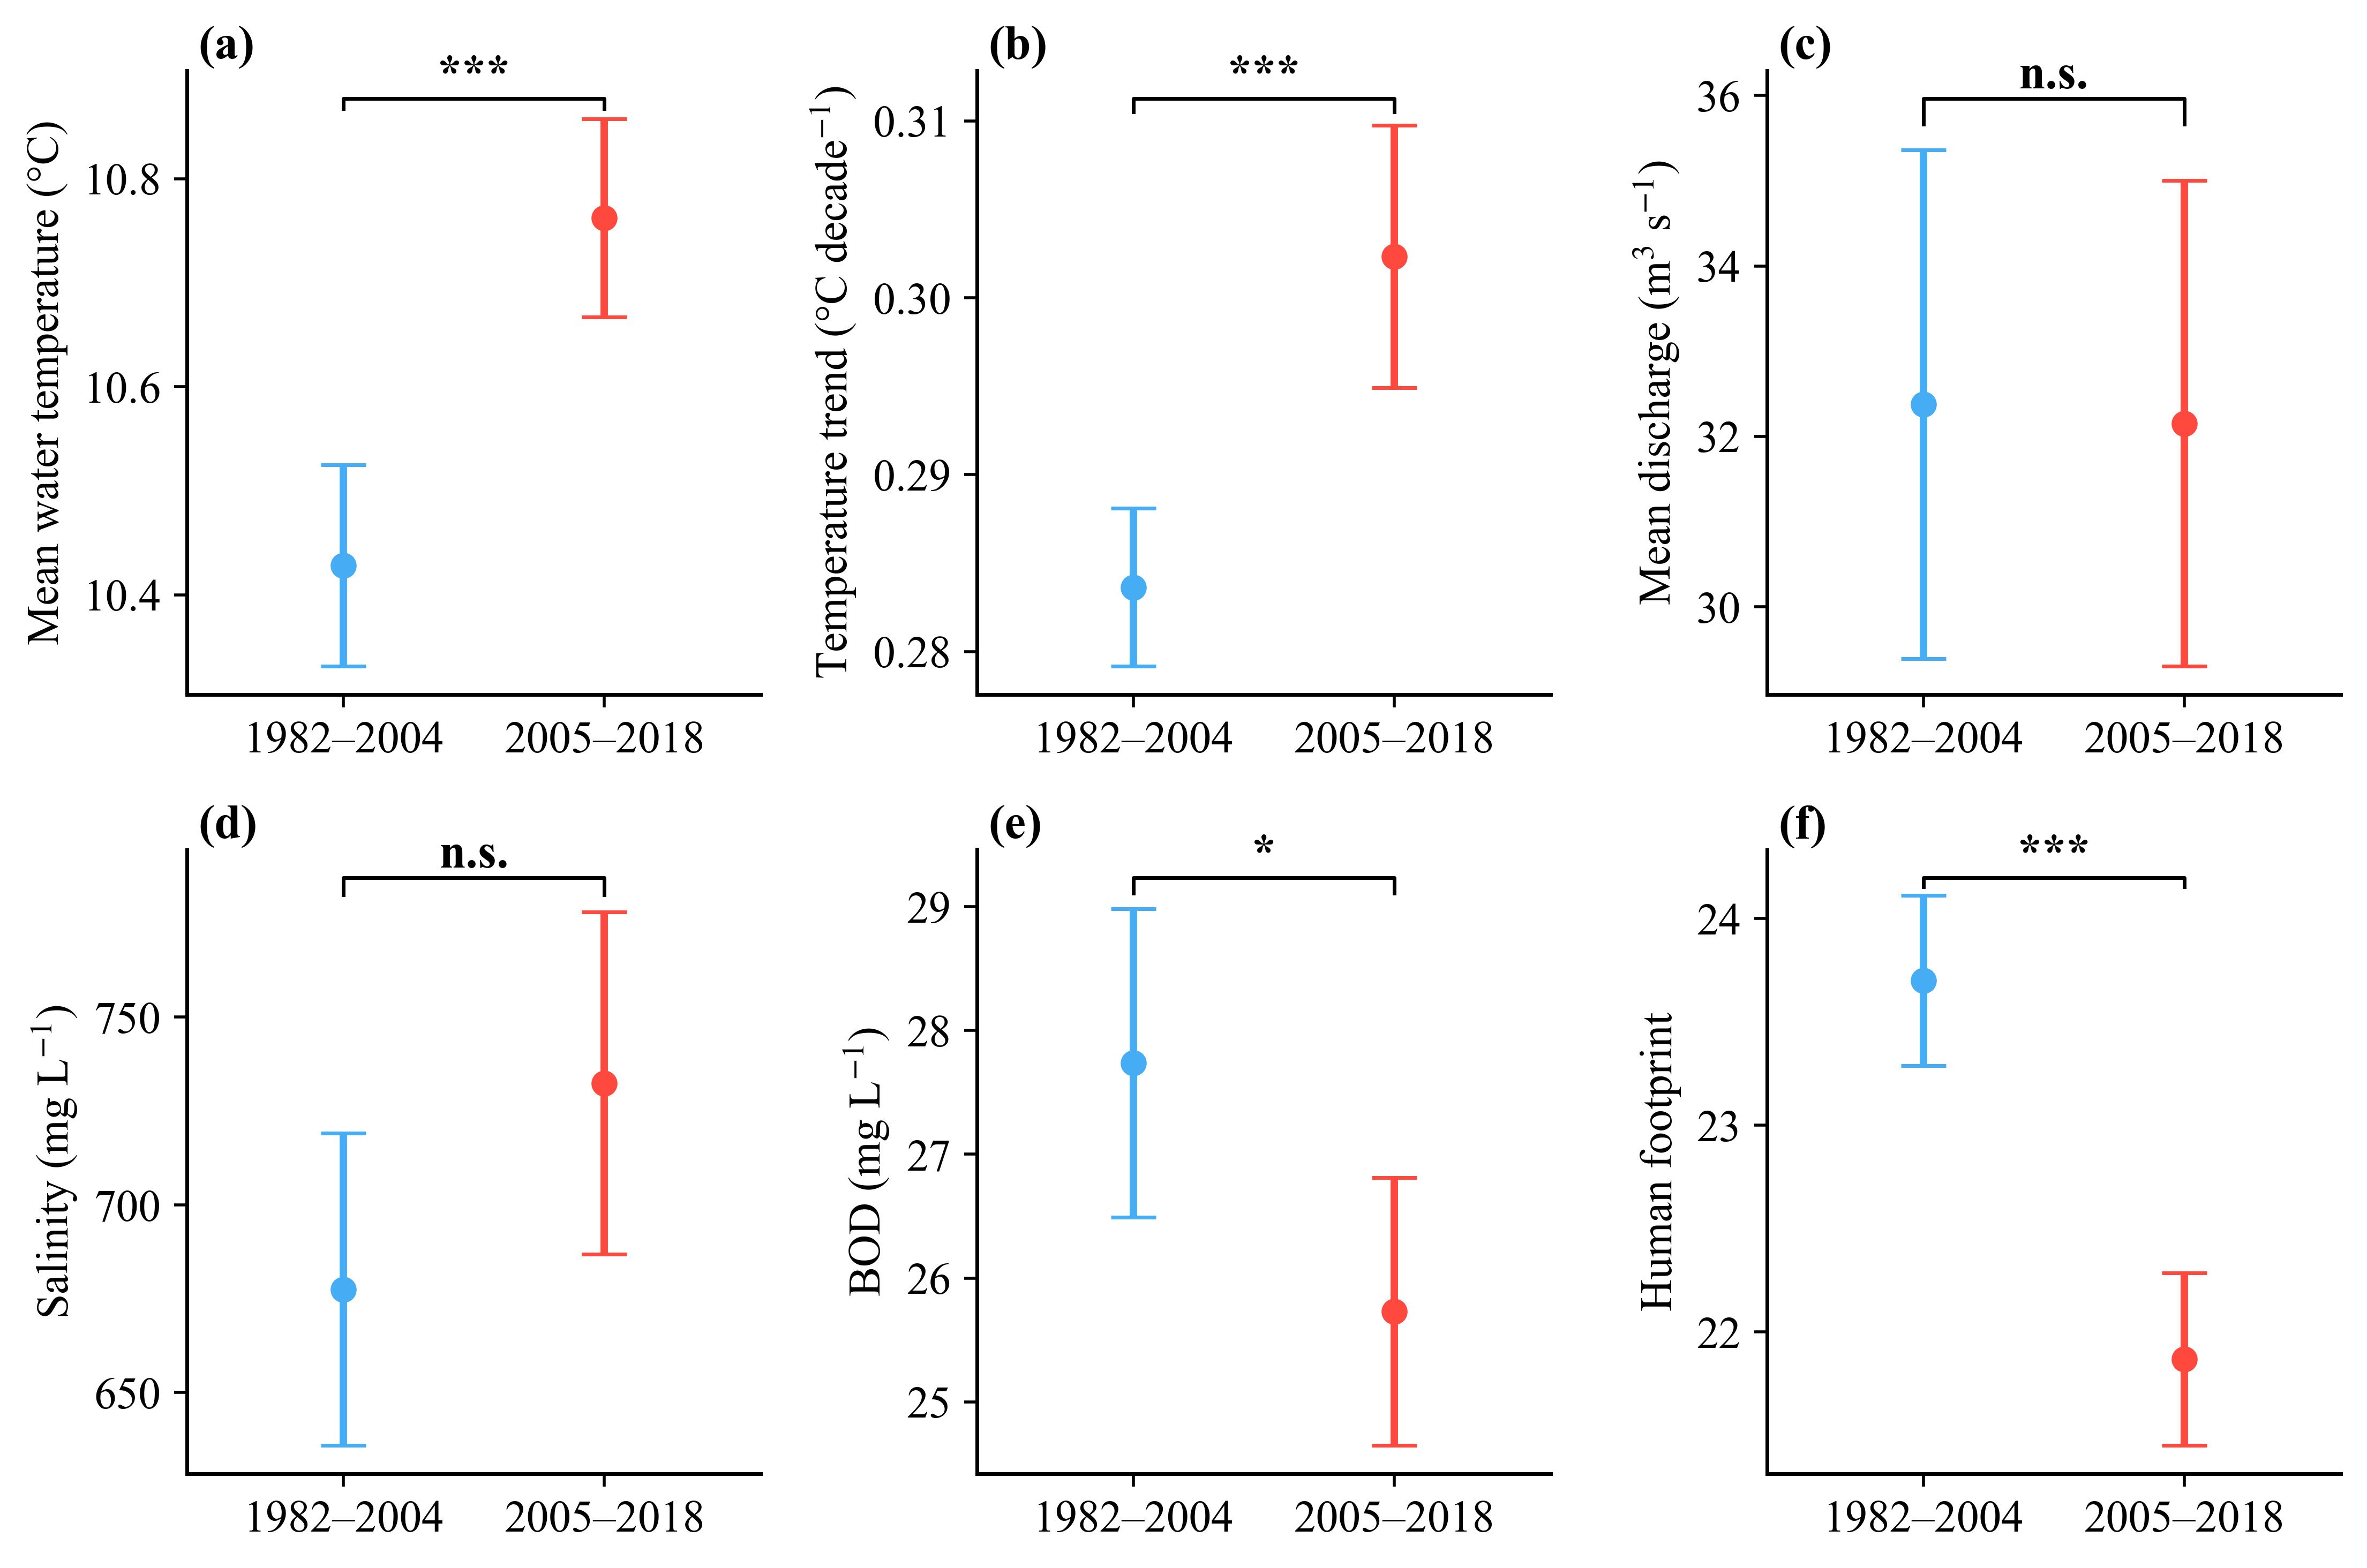

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import os
import string

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "axes.edgecolor": "black",
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.color": "black",
    "ytick.color": "black",
})

def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "n.s."

file = r"D:\NC\Data\rivernet\inputdata\Richness_segmented_2004.csv"
df = pd.read_csv(file)

df = df[df["period"].isin(["1982_2004", "2005_2018"])].copy()

env_vars = [
    "mean_temp",
    "sen_temp",
    "mean_Q",
    "mean_salinity",
    "mean_organic",
    "HFP_period"
]

ylabels = [
    "Mean water temperature (°C)",
    "Temperature trend (°C decade$^{-1}$)",
    "Mean discharge (m$^3$ s$^{-1}$)",
    "Salinity (mg L$^{-1}$)",
    "BOD (mg L$^{-1}$)",
    "Human footprint"
]

outdir = r"C:\Users\Lenovo\Desktop"
os.makedirs(outdir, exist_ok=True)
fig, axes = plt.subplots(2, 3, figsize=(9, 6), dpi=500)
axes = axes.flatten()

panel_labels = list(string.ascii_lowercase)  # ['a','b','c','d','e','f']
for i, (ax, var, ylabel) in enumerate(zip(axes, env_vars, ylabels)):

    sub = df[["period", var]].dropna()

    before = sub[sub["period"] == "1982_2004"][var].values
    after  = sub[sub["period"] == "2005_2018"][var].values
    if var == "sen_temp":
        before = before * 10.0
        after  = after  * 10.0

    if len(before) < 5 or len(after) < 5:
        ax.set_visible(False)
        continue
    mean_b = np.nanmean(before)
    mean_a = np.nanmean(after)
    se_b = np.nanstd(before, ddof=1) / np.sqrt(len(before))
    se_a = np.nanstd(after, ddof=1) / np.sqrt(len(after))
    ci_b = 1.96 * se_b
    ci_a = 1.96 * se_a
    stat, p_value = scipy.stats.ttest_ind(
        before, after, equal_var=False
    )
    p_star = convert_pvalue_to_asterisks(p_value)
    ax.errorbar(
        0, mean_b, yerr=ci_b,
        fmt="o", color="#46acf4",
        ecolor="#46acf4", elinewidth=2,
        capsize=6, markersize=6
    )
    ax.errorbar(
        1, mean_a, yerr=ci_a,
        fmt="o", color="#ff493e",
        ecolor="#ff493e", elinewidth=2,
        capsize=6, markersize=6
    )
    y_max = max(mean_b + ci_b, mean_a + ci_a)
    h = max(ci_b, ci_a) * 0.1
    y = y_max + h

    ax.plot([0, 0, 1, 1],
            [y, y + h, y + h, y],
            lw=1, c="k")
    ax.text(
        0.5, y + h,
        p_star,
        ha="center", va="bottom",
        fontsize=13, fontweight="bold"
    )
    ax.text(
        0.02, 1.07,
        f"({panel_labels[i]})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=13, fontweight="bold"
    )
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["1982–2004", "2005–2018"])
    ax.set_xlim(-0.6, 1.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.grid(False)

plt.tight_layout()
fig.savefig(
    os.path.join(outdir, "extendFig8.png"),
    dpi=500, bbox_inches="tight"
)
plt.show()